# Classification
### **Purpose:** Compare gesture classification accuracy across three methods:
1. SRC Direct (per-class dictionaries)
2. Sparse Codes + SVM (single dictionary features)
3. Classical TD Features + SVM (baseline)

In [13]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../')

import os
import matplotlib.pyplot as plt
import numpy as np
from src.config import DATABASE_CONFIGS
from src.classification import run_all_classification_experiments
from src.visualization import plot_confusion_matrix

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## CONFIGURATION

In [14]:
DATABASE = 'DB5'
SUBJECT = 1
LOAD_DIR = f'../data/preprocessed/{DATABASE}/'
prefix = f'S{SUBJECT:02d}'

N_ATOMS = 100
N_NONZERO = 5

print(f"Classification: {DATABASE} Subject {SUBJECT}")
print(f"Dictionary: {N_ATOMS} atoms, sparsity k={N_NONZERO}")

Classification: DB5 Subject 1
Dictionary: 100 atoms, sparsity k=5


## 1. Load data

In [15]:
print("\nLoading preprocessed data...")
X_train = np.load(os.path.join(LOAD_DIR, f'{prefix}_X_train.npy'))
y_train = np.load(os.path.join(LOAD_DIR, f'{prefix}_y_train.npy'))
X_test = np.load(os.path.join(LOAD_DIR, f'{prefix}_X_test.npy'))
y_test = np.load(os.path.join(LOAD_DIR, f'{prefix}_y_test.npy'))

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Classes: {sorted(np.unique(y_train))}")


Loading preprocessed data...
Train: (7826, 40, 16), Test: (3857, 40, 16)
Classes: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]


## 2. Run all classification experiments

In [16]:
results = run_all_classification_experiments(
    X_train, X_test, y_train, y_test,
    n_atoms=N_ATOMS,
    n_nonzero=N_NONZERO
)


METHOD 1: SRC Direct (Per-Class Dictionaries)
  Gesture  1:  488 windows ->  30 atoms
  Gesture  2:  417 windows ->  30 atoms
  Gesture  3:  433 windows ->  30 atoms
  Gesture  4:  449 windows ->  30 atoms
  Gesture  5:  431 windows ->  30 atoms
  Gesture  6:  462 windows ->  30 atoms
  Gesture  7:  443 windows ->  30 atoms
  Gesture  8:  446 windows ->  30 atoms
  Gesture  9:  407 windows ->  30 atoms
  Gesture 10:  414 windows ->  30 atoms
  Gesture 11:  454 windows ->  30 atoms
  Gesture 12:  428 windows ->  30 atoms
  Gesture 13:  309 windows ->  30 atoms
  Gesture 14:  303 windows ->  30 atoms


/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:757: ConvergenceWarning: Early stopping the lars path, as the residues are small and the current value of alpha is no longer well controlled. 3 iterations, alpha=2.868e-04, previous alpha=2.867e-04, with an active set of 4 regressors.
  warnings.warn(


  Gesture 15:  289 windows ->  30 atoms
  Gesture 16:  337 windows ->  30 atoms
  Gesture 17:  287 windows ->  30 atoms
  Gesture 18:  174 windows ->  30 atoms
  Gesture 19:  160 windows ->  30 atoms
  Gesture 20:  155 windows ->  30 atoms
  Gesture 21:  166 windows ->  30 atoms
  Gesture 22:  180 windows ->  30 atoms
  Gesture 23:  194 windows ->  30 atoms
  Classified 500/3857 windows...
  Classified 1000/3857 windows...
  Classified 1500/3857 windows...
  Classified 2000/3857 windows...
  Classified 2500/3857 windows...
  Classified 3000/3857 windows...
  Classified 3500/3857 windows...
Accuracy: 12.96%

METHOD 2: Sparse Codes + SVM (Single Dictionary)
Training MiniBatch Dictionary...
  Samples: 7826
  Signal dimension: 640
  Atoms: 100
  Compression ratio: 6.4:1


/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:757: ConvergenceWarning: Early stopping the lars path, as the residues are small and the current value of alpha is no longer well controlled. 72 iterations, alpha=6.810e-03, previous alpha=6.595e-03, with an active set of 67 regressors.
  warnings.warn(
/home/vscode/.local/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:757: ConvergenceWarning: Early stopping the lars path, as the residues are small and the current value of alpha is no longer well controlled. 86 iterations, alpha=1.228e-02, previous alpha=1.157e-02, with an active set of 87 regressors.
  warnings.warn(


  Encoded 7826 windows -> sparse codes shape: (7826, 100)
  Average non-zero coefficients: 64.0 (target: 5)
  Encoded 3857 windows -> sparse codes shape: (3857, 100)
  Average non-zero coefficients: 64.0 (target: 5)
Accuracy: 8.04%

METHOD 3: Classical TD Features + SVM (Baseline)
Accuracy: 51.10%

CLASSIFICATION SUMMARY
SRC Direct................: 12.96%
Sparse Codes + SVM........: 8.04%
Classical Features + SVM..: 51.10%


## 3. Visualize confusion matrix


Generating confusion matrices...


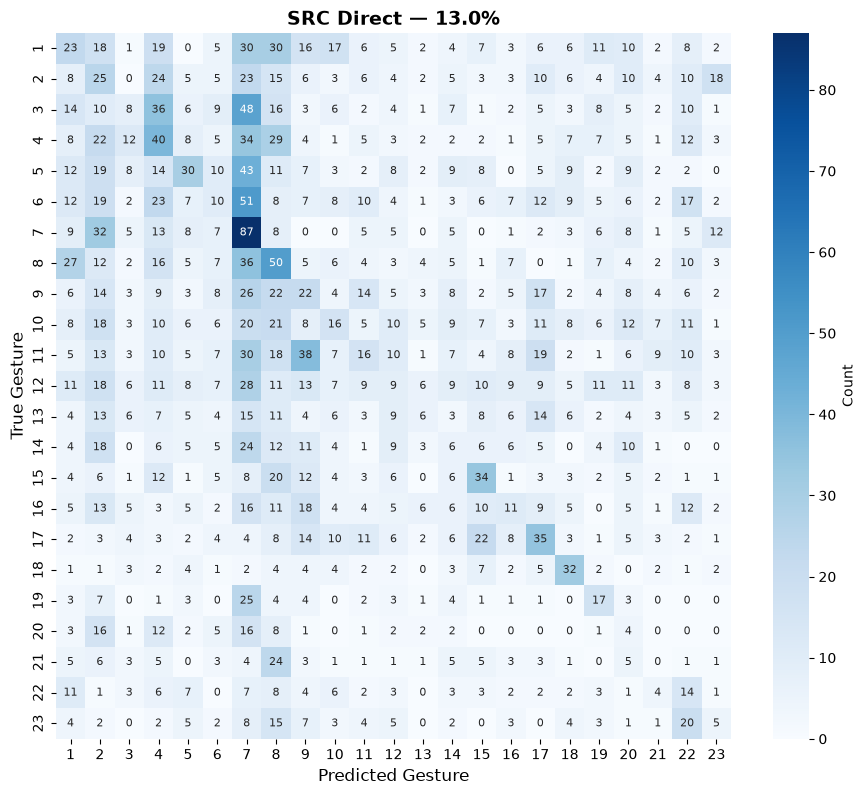

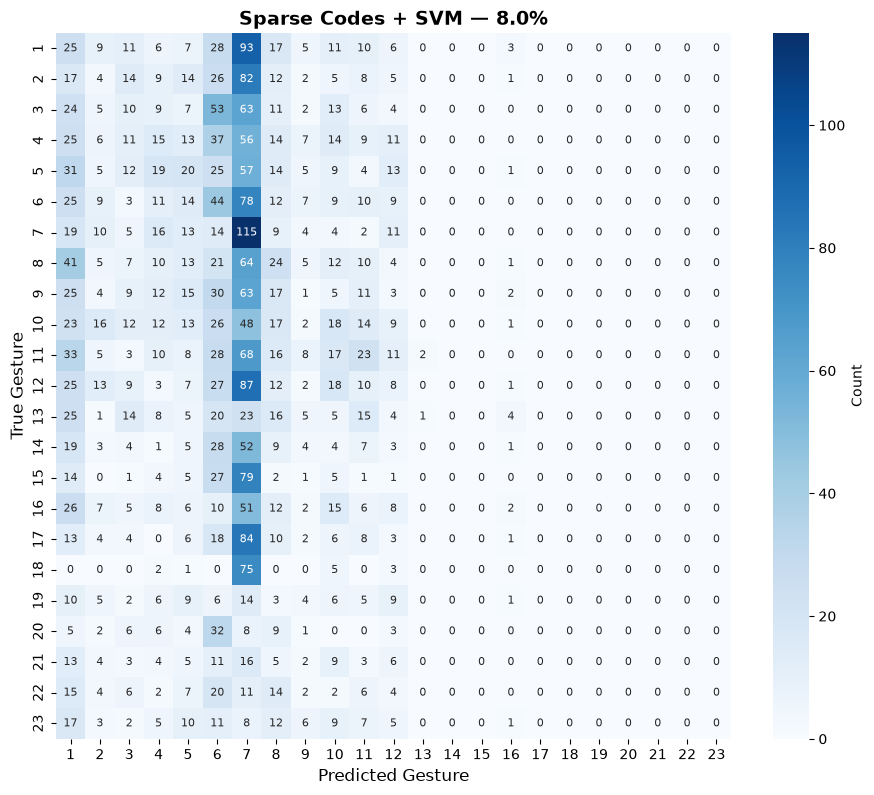

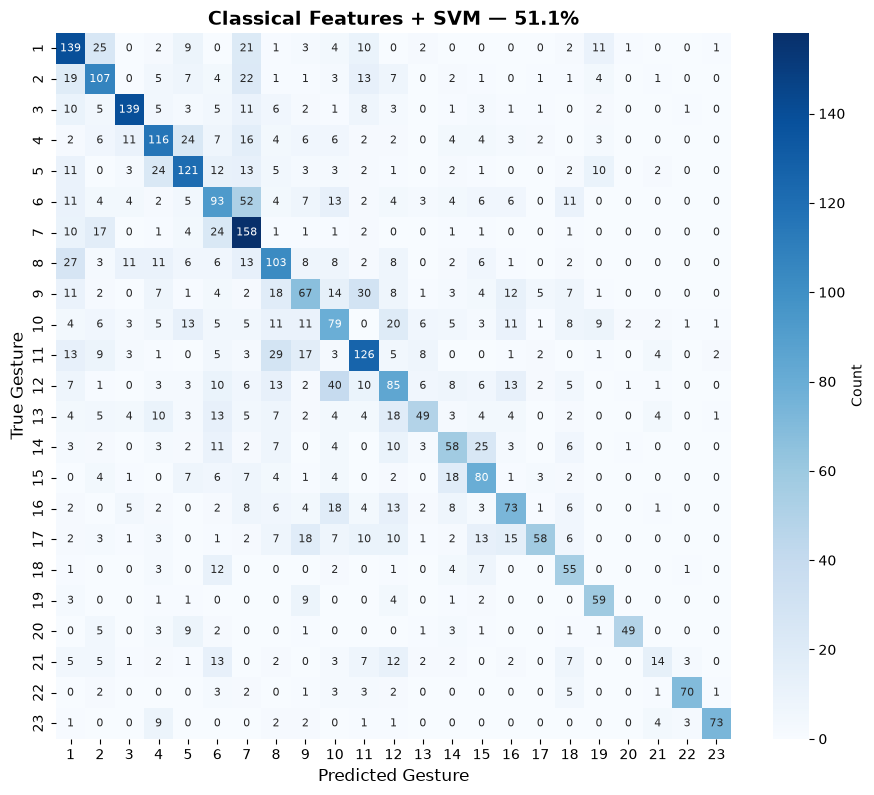

In [17]:
print("\nGenerating confusion matrices...")

fig_src = plot_confusion_matrix(
    y_test, results['src']['predictions'],
    title=f"SRC Direct — {results['src']['accuracy']*100:.1f}%"
)
plt.show()

fig_sparse = plot_confusion_matrix(
    y_test, results['sparse_svm']['predictions'],
    title=f"Sparse Codes + SVM — {results['sparse_svm']['accuracy']*100:.1f}%"
)
plt.show()

fig_classical = plot_confusion_matrix(
    y_test, results['classical_svm']['predictions'],
    title=f"Classical Features + SVM — {results['classical_svm']['accuracy']*100:.1f}%"
)
plt.show()